In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
from xgboost import XGBRegressor

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [11]:
# Load the dataset

In [14]:
df = pd.read_csv('/content/drive/MyDrive/data/customer_segmentation.csv', encoding='latin1')

In [18]:
print("df shape:", df.shape)

df shape: (541909, 8)


In [19]:
print("df sample:\n", df.head())

df sample:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
# Preprocessing: Check for nulls and basic cleaning

In [20]:
df.dropna(inplace=True)

In [28]:
# Clean column names


In [27]:
df.columns = df.columns.str.strip()

In [24]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [29]:
# Convert 'InvoiceDate' to datetime

In [30]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [31]:
# Drop missing CustomerIDs

In [32]:
df = df.dropna(subset=['CustomerID'])

In [33]:
# Snapshot date (latest invoice date + 1 day)

In [34]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [35]:
# Feature Engineering: Recency, Frequency, AOV

In [36]:
customer_data = df.groupby('CustomerID').agg({
    'InvoiceDate': [
        lambda x: (snapshot_date - x.max()).days,  # Recency
        'count'  # Frequency
    ],
    'UnitPrice': 'mean'  # Average Order Value (AOV)
})

In [37]:
# Rename columns

In [38]:
customer_data.columns = ['Recency', 'Frequency', 'AOV']

In [39]:
customer_data.reset_index(inplace=True)

In [40]:
# Simulate Customer LTV (if real LTV not available)

In [41]:
np.random.seed(42)

In [42]:
customer_data['CustomerLTV'] = customer_data['Frequency'] * customer_data['AOV'] * np.random.uniform(1, 2, customer_data.shape[0])

In [43]:
# Features and Target

In [44]:
X = customer_data[['Recency', 'Frequency', 'AOV']]

In [45]:
y = customer_data['CustomerLTV']

In [46]:
# Train-test split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Model Training - Random Forest

In [49]:
rf = RandomForestRegressor(random_state=42)

In [50]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [51]:
# Optional Model Training - XGBoost

In [52]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

In [53]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [54]:
# Predictions

In [55]:
y_pred_rf = rf.predict(X_test)

In [56]:
y_pred_xgb = xgb.predict(X_test)

In [57]:
# Evaluation

In [59]:
print("\nRandom Forest Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("\nXGBoost Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))



Random Forest Performance:
MAE: 133.31192939867915
RMSE: 870.8257093696484

XGBoost Performance:
MAE: 426.1469225479518
RMSE: 4209.75364961073


In [60]:
# Add Predicted LTV to customer_data

In [61]:
customer_data['PredictedLTV'] = rf.predict(X)

In [62]:
# Customer Segmentation based on Predicted LTV

In [63]:
customer_data['Segment'] = pd.qcut(customer_data['PredictedLTV'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

In [66]:
print("\nFinal Segmented Customer Data:\n", customer_data.head())


Final Segmented Customer Data:
    CustomerID  Recency  Frequency       AOV  CustomerLTV  PredictedLTV  \
0     12346.0      326          2  1.040000     2.859043      2.793996   
1     12347.0        2        182  2.644011   938.703231    832.102392   
2     12348.0       75         31  5.764839   309.524637    297.829900   
3     12349.0       19         73  8.289041   967.348249   1016.434843   
4     12350.0      310         17  3.841176    75.488017     81.195128   

    Segment  
0       Low  
1      High  
2  Mid-High  
3      High  
4   Mid-Low  


In [67]:
# Visualization

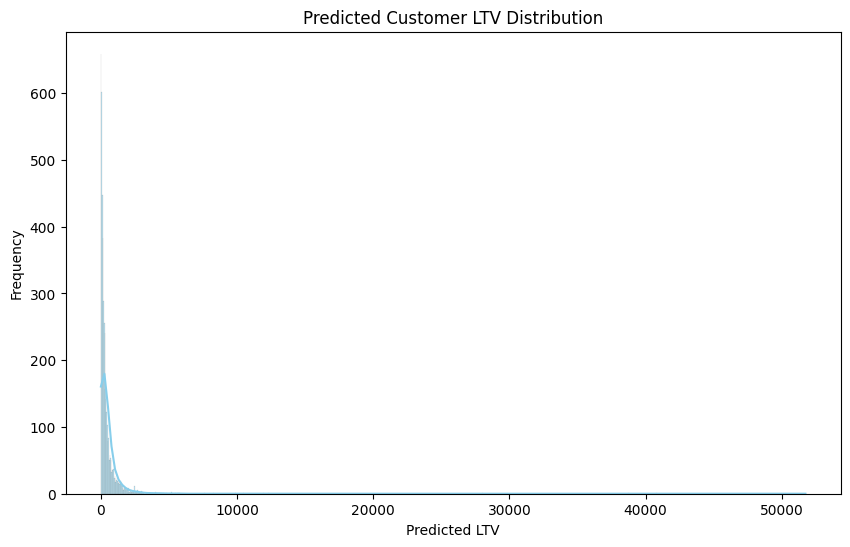

In [75]:
plt.figure(figsize=(10,6))
sns.histplot(customer_data['PredictedLTV'], kde=True, color='skyblue')
plt.title('Predicted Customer LTV Distribution')
plt.xlabel('Predicted LTV')
plt.ylabel('Frequency')
plt.show()

In [78]:
# Save final results

In [79]:
customer_data.to_csv('/content/drive/MyDrive/data/final_ltv_predictions.csv', index=False)
print("\nFinal LTV predictions saved as 'final_ltv_predictions.csv'.")


Final LTV predictions saved as 'final_ltv_predictions.csv'.
